In [84]:
from shinka.utils import load_programs_to_df

path = "results/results_piet1_async_small/"
programs_df, prompts_df = load_programs_to_df(path, include_prompts=True)

Total program rows: 16
Correct program rows: 4
Total cost: $0.09
Avg cost per program: $0.01
Total prompt rows: 3
Prompts in archive: 3


In [85]:
programs_df.head()

,id,code,language,parent_id,archive_inspiration_ids,top_k_inspiration_ids,generation,timestamp,complexity,embedding,...,meta_cost,meta_recommendations,meta_summary,meta_scratch_pad,_spawned_island,_spawned_from_program_id,_spawn_island_idx,_spawn_strategy,_spawned_as_child,total_cost
0,cc2e5476-5353-4510-8681-4ed21cda4c6a,from dataclasses import dataclass\nfrom typing...,python,NaN,[],[],0,2026-03-13 16:37:44.272169113,0.716,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
1,c873628f-88d8-427c-86f1-5b02c0ac8846,from dataclasses import dataclass\nfrom typing...,python,cc2e5476-5353-4510-8681-4ed21cda4c6a,[],[],1,2026-03-13 16:37:53.539737940,0.725,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004086
2,13a8d233-78b6-408d-b82e-9d8b74957a47,from dataclasses import dataclass\nfrom typing...,python,cc2e5476-5353-4510-8681-4ed21cda4c6a,[],[],2,2026-03-13 16:37:54.602478981,0.736,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.004641
3,17bb5343-d2dd-42cf-b664-11a2d5a5a30d,from dataclasses import dataclass\nfrom typing...,python,cc2e5476-5353-4510-8681-4ed21cda4c6a,[],[],3,2026-03-13 16:38:02.347541094,0.724,[],...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003703
4,a38e5ffd-47b9-4af1-b93d-cf28e2bef596,from dataclasses import dataclass\nfrom typing...,python,cc2e5476-5353-4510-8681-4ed21cda4c6a,[],[],4,2026-03-13 16:38:02.468425035,0.751,[],...,0.012763,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.016361


Filtered to 4 'correct' rows from 16 total.
GraphViz not available, using hierarchical layout


/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/shinka/plots/plot_lineage_tree.py:384: UserWarning: 

The arrowsize keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default values.
Note that using FancyArrowPatches may be slow for large graphs.

  nx.draw_networkx_edges(
/Users/henry/Documents/ShinkaEvolve/.venv/lib/python3.14/site-packages/networkx/drawing/nx_pylab.py:1497: UserWarning: You passed a edgecolor/edgecolors ('darkred') for an unfilled marker (np.str_('x')).  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  node_collection = ax.scatter(


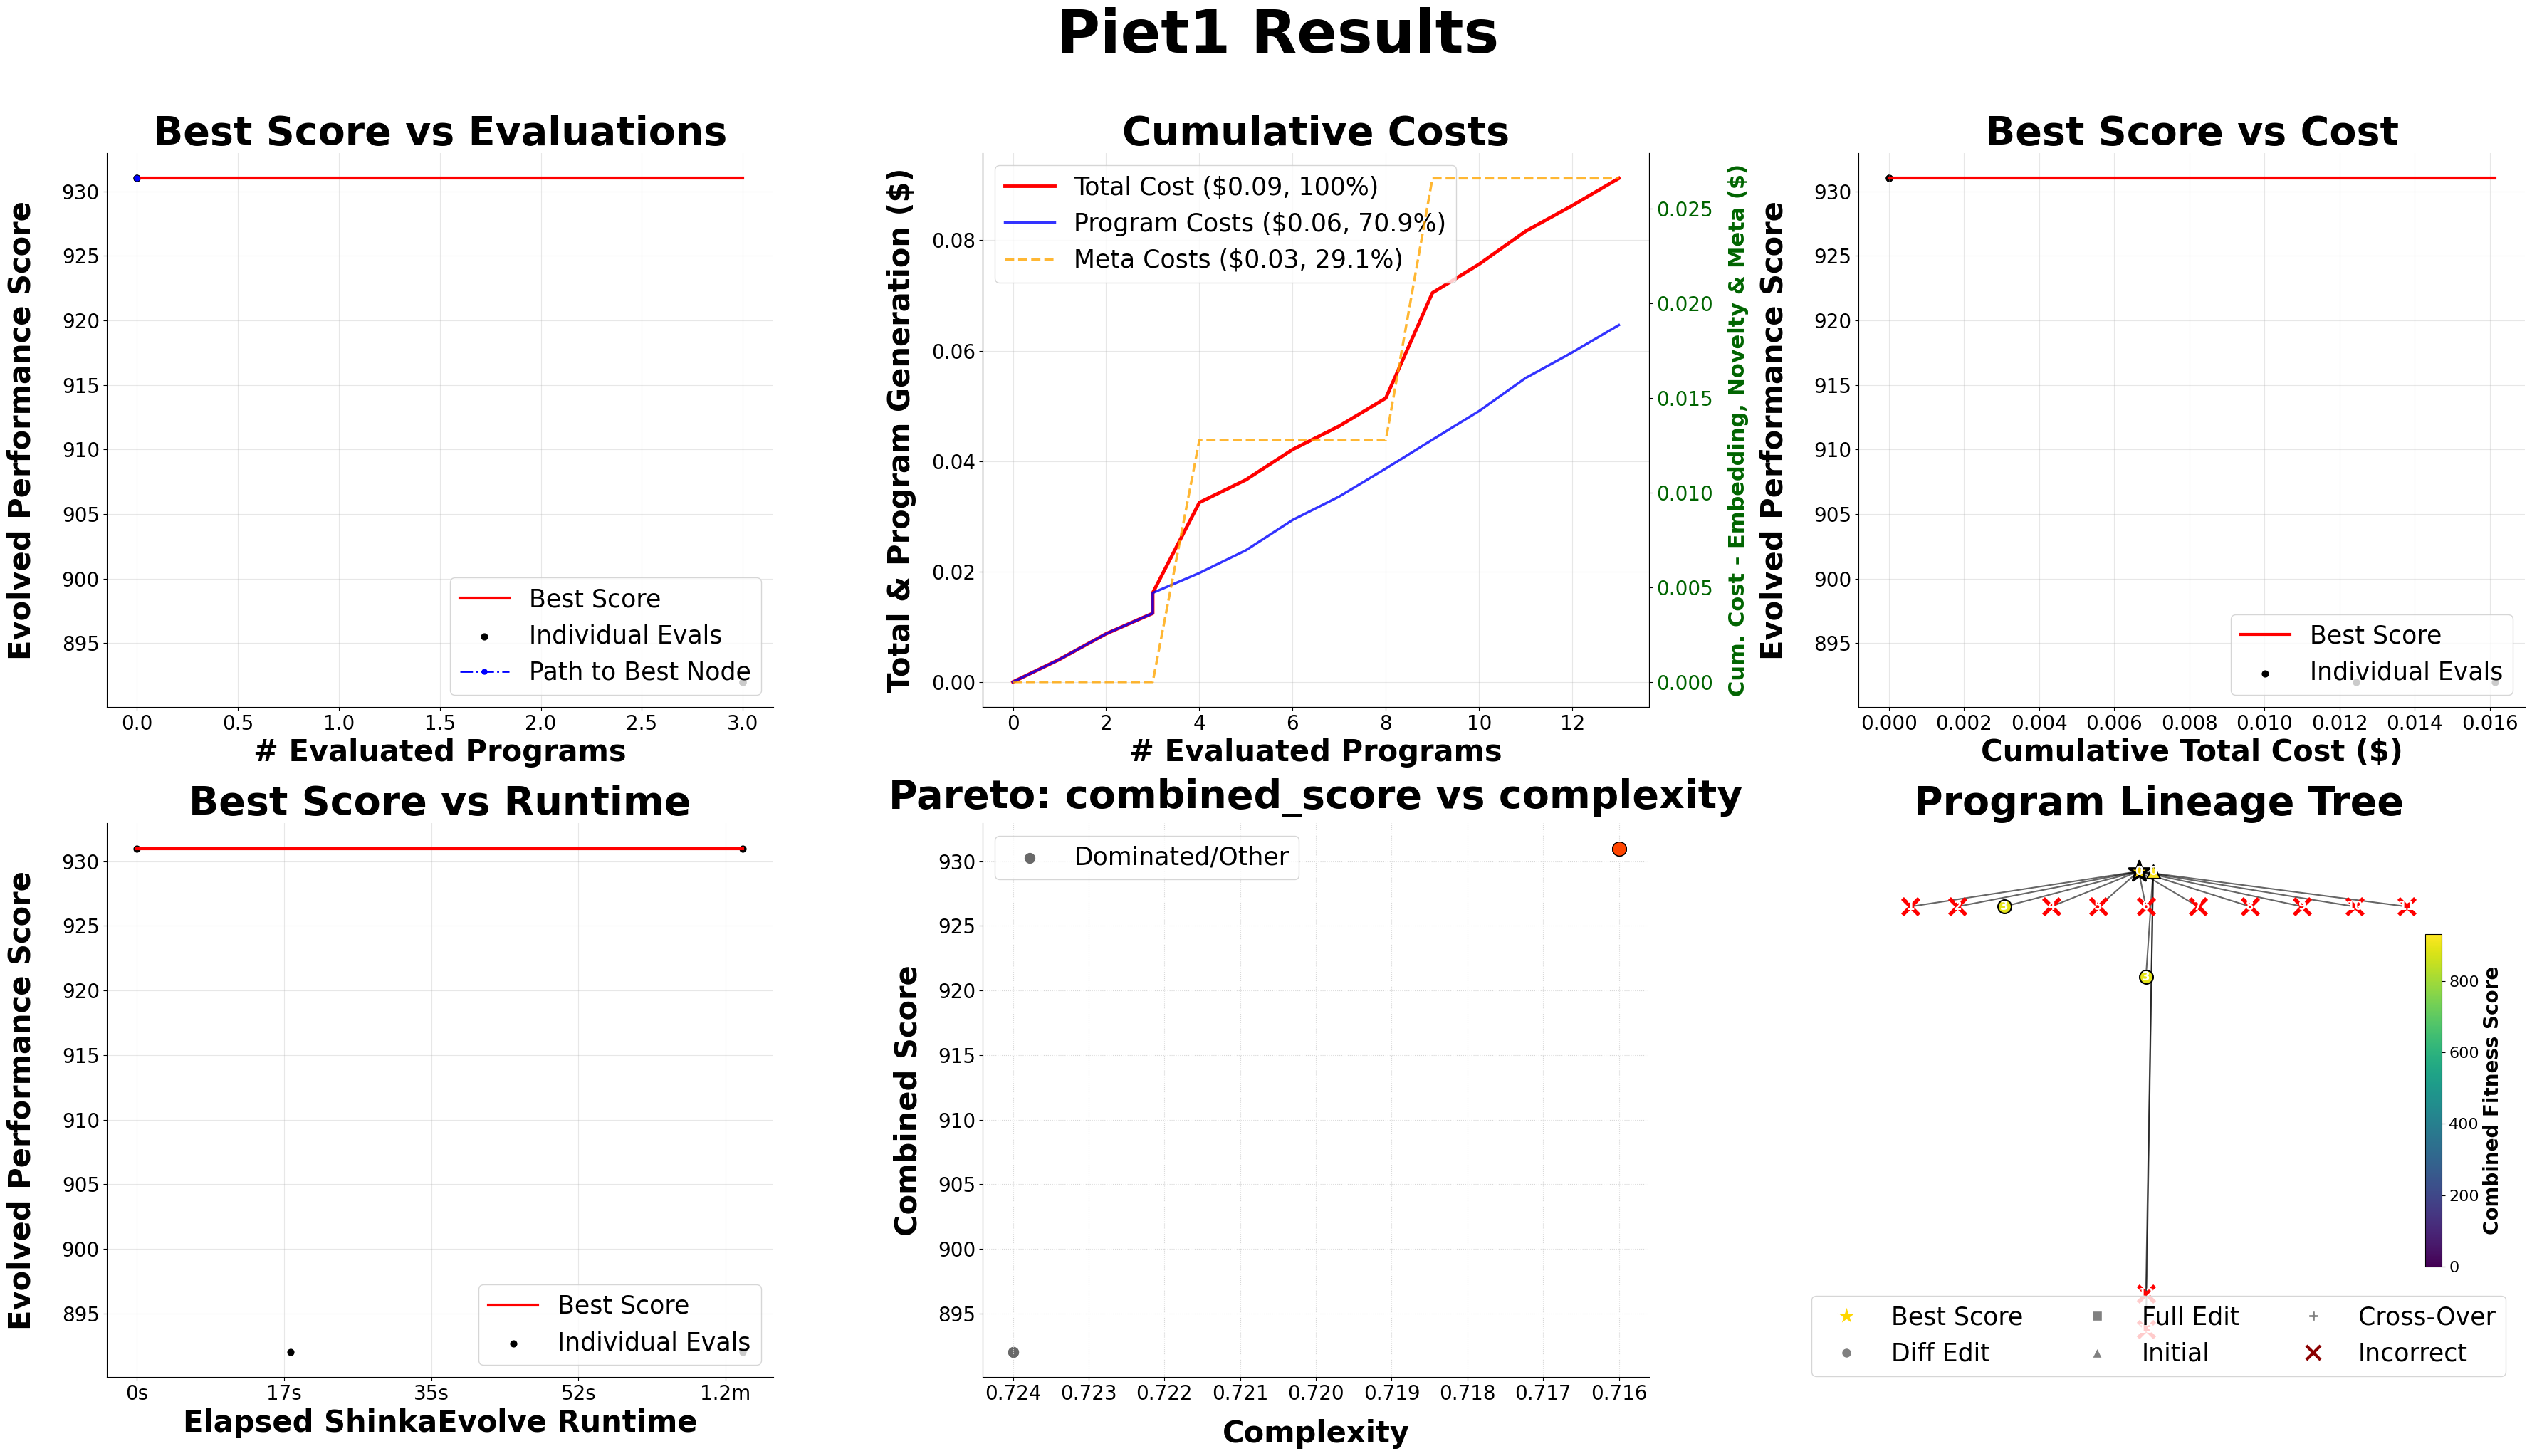

In [86]:
import matplotlib.pyplot as plt

from shinka.plots import plot_evals_performance
from shinka.plots import plot_costs
from shinka.plots import plot_cost_performance
from shinka.plots import plot_time_performance
from shinka.plots import plot_pareto_curve
from shinka.plots import plot_lineage_tree

if programs_df is None or programs_df.empty:
    raise ValueError(
        "No program data loaded. Update `path` in cell 0 to a valid results directory."
    )

fig, axs = plt.subplots(2, 3, figsize=(36, 20))
fig.suptitle("Piet1 Results", fontsize=60, weight="bold", y=1.02)

plot_evals_performance(
    programs_df,
    title="Best Score vs Evaluations",
    fig=fig,
    ax=axs[0, 0],
    annotate=False,
    show_cost=False,
)

plot_costs(
    programs_df,
    title="Cumulative Costs",
    fig=fig,
    ax=axs[0, 1],
)

plot_cost_performance(
    programs_df,
    title="Best Score vs Cost",
    fig=fig,
    ax=axs[0, 2],
)

plot_time_performance(
    programs_df,
    title="Best Score vs Runtime",
    fig=fig,
    ax=axs[1, 0],
)

# Pick a Pareto pair that usually exists in Shinka results.
if "loc" in programs_df.columns:
    pareto_x, pareto_y = "loc", "combined_score"
    x_maximize, y_maximize = False, True
elif "complexity" in programs_df.columns:
    pareto_x, pareto_y = "complexity", "combined_score"
    x_maximize, y_maximize = False, True
elif "total_cost" in programs_df.columns:
    pareto_x, pareto_y = "total_cost", "combined_score"
    x_maximize, y_maximize = False, True
else:
    pareto_x, pareto_y = "generation", "combined_score"
    x_maximize, y_maximize = True, True

plot_pareto_curve(
    programs_df,
    x_variable=pareto_x,
    y_variable=pareto_y,
    x_maximize=x_maximize,
    y_maximize=y_maximize,
    title=f"Pareto: {pareto_y} vs {pareto_x}",
    fig=fig,
    ax=axs[1, 1],
    annotate=False,
)

plot_lineage_tree(
    programs_df,
    title="Program Lineage Tree",
    fig=fig,
    ax=axs[1, 2],
)

plt.tight_layout()
plt.show()
